# Cross-lithology comparison

Everything in this study that compares augen gneiss with psammitic schist, or
fits a model to both at once. The per-specimen fields for each rock are in
`Tensile_augen_gneiss.ipynb` and `Tensile_psammitic_schist.ipynb`.

**This notebook contains no function definitions.** The sections below call
`tools/analysis/`, the same package the lithology notebooks use, so a model
fitted here and a field plotted there cannot disagree about the rock.

## 1. Environment

In [1]:
%matplotlib inline
# Inline is the default under ipykernel, but stating it makes the stored
# outputs of a batch `nbconvert --execute` run independent of that default.

import numpy as np, pandas as pd, matplotlib

from tools import lithology, analysis, output_dirs
from tools.plot_style import apply_plot_style

output_dirs.ensure(*output_dirs.ALL)   # a clean checkout carries no outputs/

TICKS = apply_plot_style()

GNEISS, SCHIST = lithology.AUGEN_GNEISS, lithology.PSAMMITIC_SCHIST
print('numpy', np.__version__, '| pandas', pd.__version__,
      '| matplotlib', matplotlib.__version__)
for r in (GNEISS, SCHIST):
    print(f'{r.display_name:18s} samples {r.sample_ids}  '
          f'spacing {r.spacing_m * 1e3:.1f} mm')

numpy 2.2.6 | pandas 2.2.3 | matplotlib 3.10.3
Augen gneiss       samples (1, 2, 3, 4, 5, 6, 7)  spacing 10.0 mm
Psammitic schist   samples (8, 9, 10, 11, 12, 13, 14)  spacing 2.0 mm


## 2. Mixed-mode fraction against k_max

The mixed-mode area fraction as the local damage cap is swept, computed
separately for the gneiss and schist specimen groups.

Sweep table saved to /Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/outputs/tables/kmax_softening_sweep.csv
  specimen-to-specimen SD: gneiss 0.24-0.26, schist 0.23-0.25 (mean level 0.20 and 0.19)
Best kC_max for Augen gneiss      : 0.050
Best kT_max for Augen gneiss      : 0.017
Best kC_max for Psammitic schist  : 0.050
Best kT_max for Psammitic schist  : 0.017

Metric used for selection: mixed / failed_total
Selection rule: smallest k within 98.0% of peak metric
Model: local anisotropic energy-driven damage softening
Figure saved to /Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/outputs/figures/kmax_local_anisotropic_mixed_fraction.pdf
Figure saved to /Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/kmax_local_anisotropic_mixed_fraction.pdf


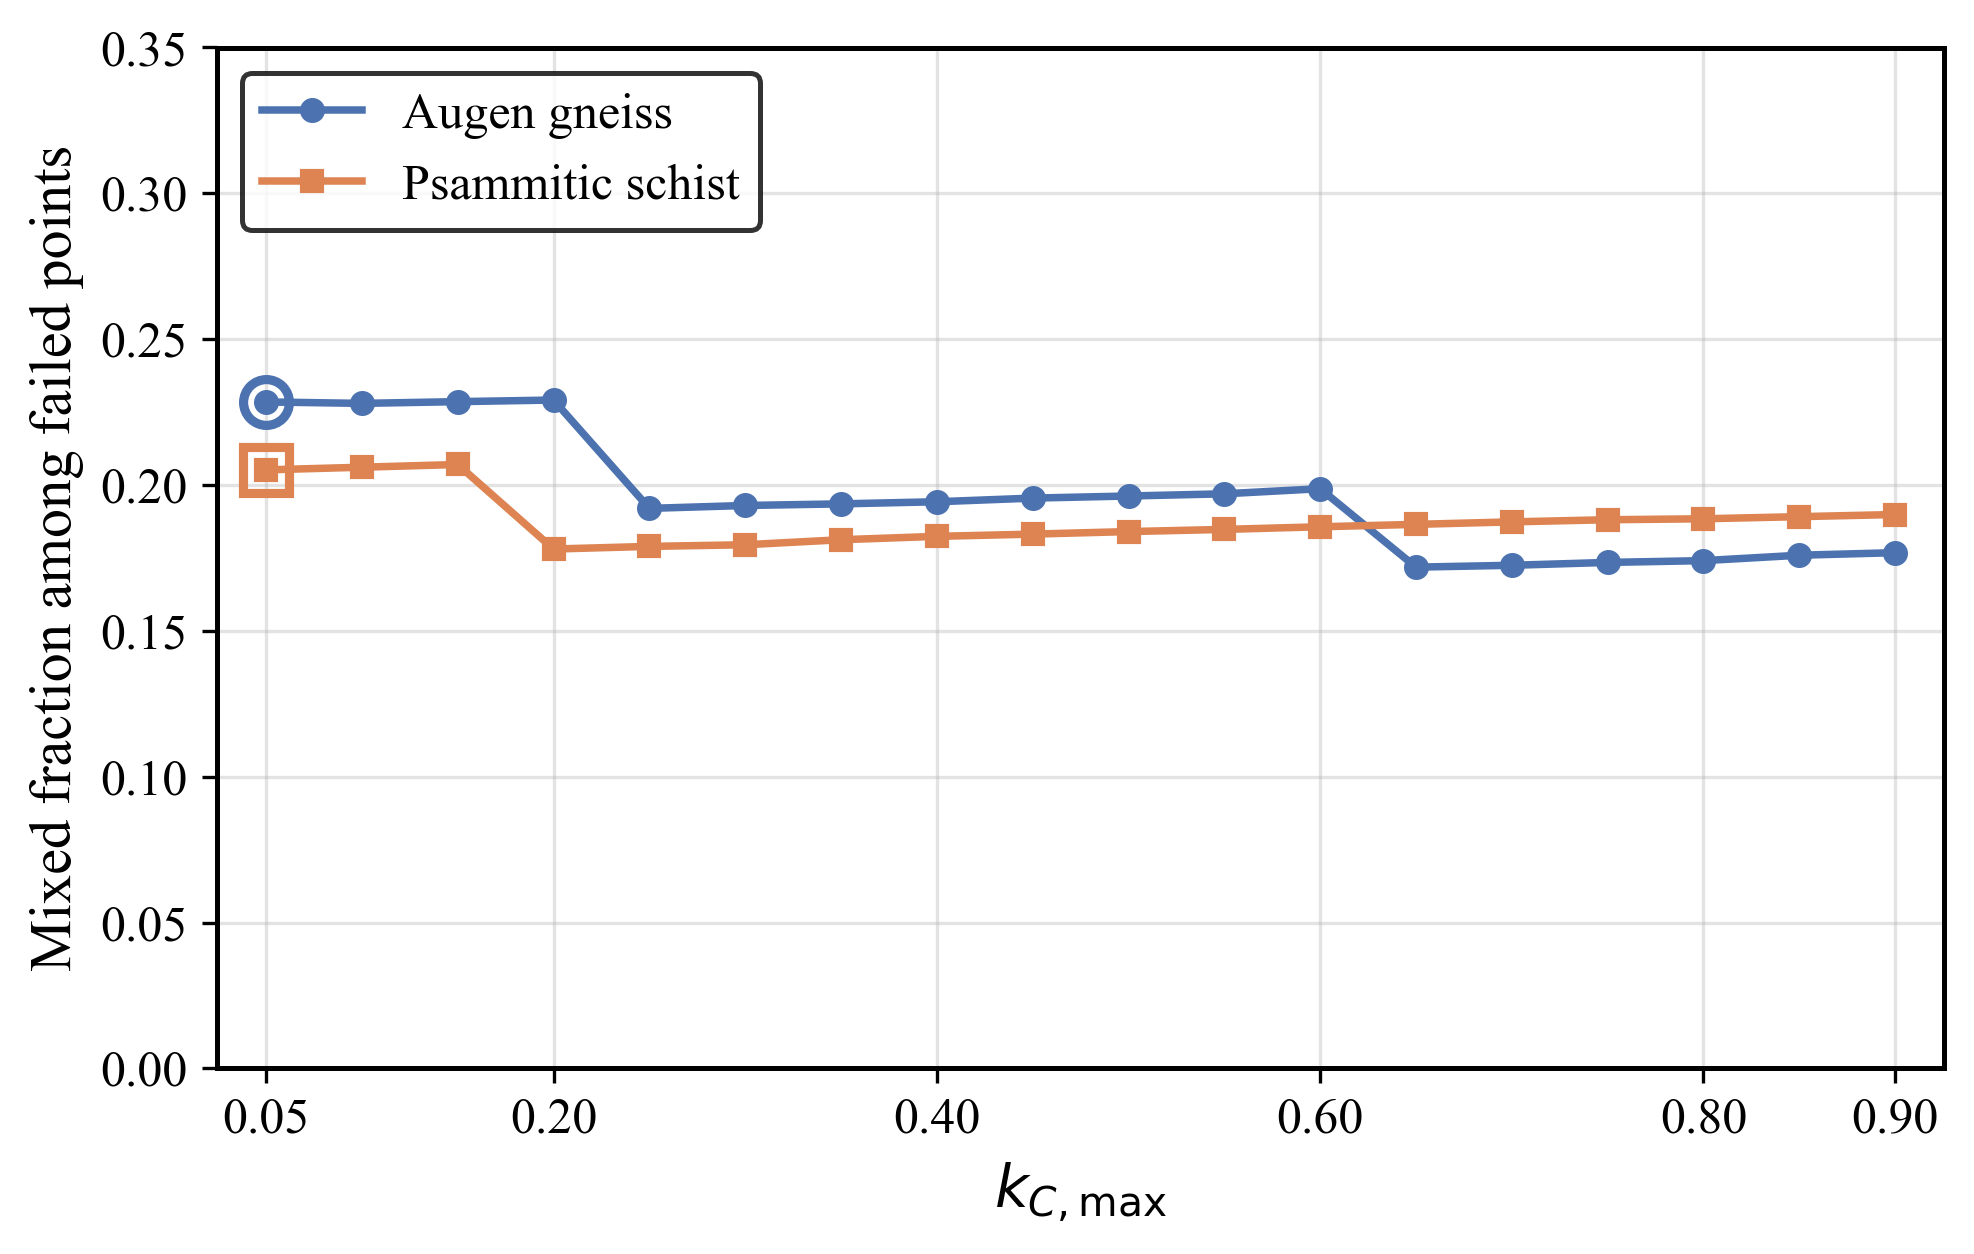

In [2]:
analysis.kmax_sweep.main()

## 3. Local Mohr-Coulomb classification

The local Mohr-Coulomb failure-mode classification over all fourteen
specimens, across the spacing and heterogeneity grid.

In [3]:
analysis.mohr_coulomb_local.main()



==== SAMPLE 1 ====
Rock type : Augen gneiss
kC_max used: 0.050
kT_max used: 0.018

--- SPACING EFFECT (heterogeneity fixed) ---
Spacing = 0.0000 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0010 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0020 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0030 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0040 m -> ΔFailure:      0  (  0.00 %)

--- MATERIAL HETEROGENEITY EFFECT (spacing fixed) ---
Heterogeneity = 0.00 -> ΔFailure:      0  (  0.00 %)
Heterogeneity = 0.10 -> ΔFailure:      0  (  0.00 %)
Heterogeneity = 0.20 -> ΔFailure:      0  (  0.00 %)
Heterogeneity = 0.30 -> ΔFailure:      0  (  0.00 %)
Heterogeneity = 0.40 -> ΔFailure:     48  (  2.56 %)


==== SAMPLE 2 ====
Rock type : Augen gneiss
kC_max used: 0.050
kT_max used: 0.018

--- SPACING EFFECT (heterogeneity fixed) ---
Spacing = 0.0000 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0010 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.0020 m -> ΔFailure:      0  (  0.00 %)
Spacing = 0.

## 4. Metric export

The formatted spreadsheet of manuscript values.

In [4]:
analysis.metric_export.main()

Excel file saved to: rock_strength_metrics.xlsx


---

# Consolidated cross-lithology diagnostics

Strength anisotropy in both loading modes, the asymmetric strength envelope and
its fit, the fabric-resolved tractions, failure statistics counted from the
fields rather than carried as literals, sensitivity to spacing and disorder, the
softening cap, fracture-trace validation against a loading-direction null, the
supplementary bounds, and a check that every graphic the manuscript cites
exists.

Per-lithology diagnostics stay in the two lithology notebooks. Every cell here
is self-contained.

In [5]:
from pathlib import Path
import warnings
import numpy as np, pandas as pd

warnings.filterwarnings("ignore")
REPO = Path.cwd()          # notebooks run from the repository root, so
                           # tools/ is importable without touching sys.path

from tools.figure_scripts import run
from tools import fabric_tractions as ft
from tools.data_io import load_specimen_table, load_replicate_table

assert len(ft.field_files()) == 14, "run both lithology notebooks first"
print(f"{len(load_specimen_table())} specimens, "
      f"{len(load_replicate_table())} replicate measurements, 14 fields")

14 specimens, 52 replicate measurements, 14 fields


In [6]:
# Strength anisotropy, both loading modes, from the replicate table
from tools import strength_anisotropy as sa
print(sa.per_angle_means().to_string(index=False))
print()
r = sa.anisotropy_ratios().set_index("lithology")
for lit in r.index:
    print(f"{lit:17s} tensile {r.loc[lit,'tensile_anisotropy']:.2f}  "
          f"compressive {r.loc[lit,'compressive_anisotropy']:.2f}  "
          f"separation {abs(r.loc[lit,'relative_separation_pct']):.0f}%")

       lithology  angle_deg  tensile_MPa  compressive_MPa  n_replicates
    Augen gneiss          0    10.470000        55.472000             5
    Augen gneiss         15    10.026000        50.884000             5
    Augen gneiss         30     9.794000        38.514000             5
    Augen gneiss         45     9.147500        45.067500             4
    Augen gneiss         60     7.910000        48.950000             3
    Augen gneiss         75     7.630000        61.342500             4
    Augen gneiss         90     8.000000        67.462500             4
Psammitic schist          0     9.570000        40.506667             3
Psammitic schist         15     8.436667        40.293333             3
Psammitic schist         30     8.106667        28.026667             3
Psammitic schist         45     6.860000        25.666667             3
Psammitic schist         60     5.900000        36.830000             3
Psammitic schist         75     3.467500        39.602500       

In [7]:
# Asymmetric strength envelope, and the cosine law fitted to the same data.
# End members are measured, so only the depth and position of the weakening
# are fitted; intervals are profile-likelihood ranges.
from scipy.optimize import curve_fit
from tools import ati_model as A
from tools.ati_model import cosine_law

d = load_replicate_table()

rows = []
for rock in ("Augen gneiss", "Psammitic schist"):
    sub = d[d.Rock_type == rock].dropna(subset=["Angle", "Tensile_strength_Mpa"])
    fit = A.fit(sub)
    e_lo, e_hi, *_ = A.profile_interval(fit, "eta", 0.0, 6.0, 0.05)
    b_lo, b_hi, *_ = A.profile_interval(fit, "beta_peak", 45.0, 89.0, 1.0)
    x, y = sub.Angle.to_numpy(float), sub.Tensile_strength_Mpa.to_numpy(float)
    p, _ = curve_fit(cosine_law, x, y, p0=[y.mean(), -1.0, 70.0], maxfev=200000)
    dense = np.linspace(0, 90, 4001)
    rows.append(dict(lithology=rock, eta=fit["eta"], eta_lo=e_lo, eta_hi=e_hi,
                     beta_p=fit["beta_peak_deg"], beta_lo=b_lo, beta_hi=b_hi,
                     R2=fit["R2"], chi2_red=fit["chi2_red"],
                     envelope_min=fit["model_min_deg"],
                     cosine_min=dense[np.argmin(cosine_law(dense, *p))]))
env = pd.DataFrame(rows)
print(env.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print()
for _, q in env.iterrows():
    print(f"{q.lithology:17s} envelope minimum {q.envelope_min:5.1f} deg, "
          f"cosine law {q.cosine_min:5.1f} deg, measured 75 deg")

       lithology   eta  eta_lo  eta_hi  beta_p  beta_lo  beta_hi    R2  chi2_red  envelope_min  cosine_min
    Augen gneiss 0.193   0.150   0.300  72.597   66.000   76.000 0.887     1.071        75.285      85.410
Psammitic schist 2.365   0.950   2.400  83.537   82.000   84.000 0.912     1.630        83.610      86.828

Augen gneiss      envelope minimum  75.3 deg, cosine law  85.4 deg, measured 75 deg
Psammitic schist  envelope minimum  83.6 deg, cosine law  86.8 deg, measured 75 deg


Augen gneiss      R2=0.887  chi2red=1.07  eta=0.193  beta_p=72.6  (400/400 bootstrap fits converged)
  Psammitic schist  R2=0.912  chi2red=1.63  eta=2.365  beta_p=83.5  (400/400 bootstrap fits converged)

  written: Anisotropic_model_smooth_endpoint_both_rocks.pdf
  [display] Anisotropic_model_smooth_endpoint_both_rocks.pdf: ModuleNotFoundError: No module named 'fitz'
Augen gneiss      W_min = 0.915 at beta_p = 72.6 deg (eta = 0.193);  sigma/sigma_0 minimum 0.711 at 75.2 deg
  Psammitic schist  W_min = 0.545 at beta_p = 83.5 deg (eta = 2.365);  sigma/sigma_0 minimum 0.286 at 83.6 deg

  written: Smooth_weakening_factor_both_rocks.pdf
  [display] Smooth_weakening_factor_both_rocks.pdf: ModuleNotFoundError: No module named 'fitz'
ordinary least squares: slope 0.961, intercept 0.221 MPa
  Augen gneiss: RMSE 0.374 MPa, R2 0.887, chi2_red 1.07
  Psammitic schist: RMSE 0.622 MPa, R2 0.912, chi2_red 1.63

written: manuscript/predicted_vs_actual_both_rocks.pdf
  [display] predicted_vs_actual_b

**fig_S_ati_profiles.png**

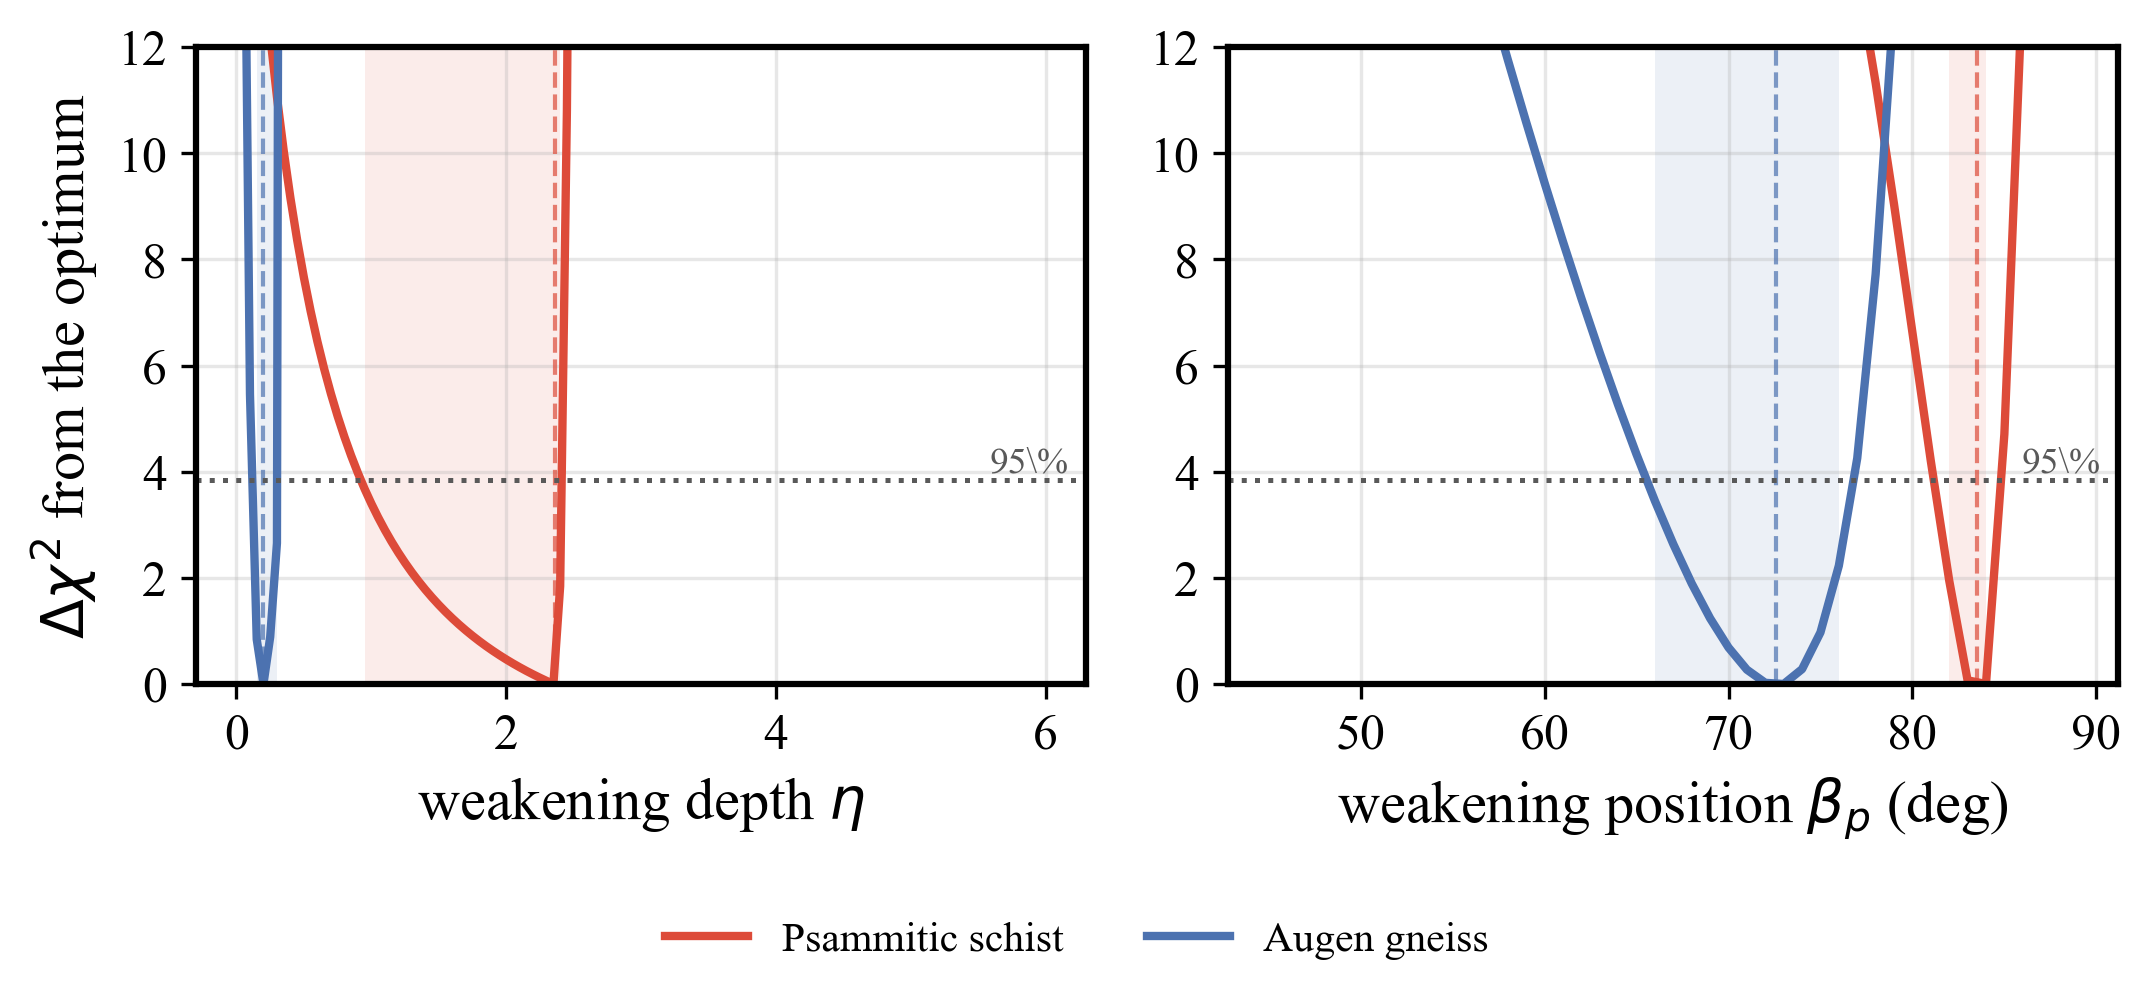

  [display] augen_gneiss_stress_distribution_graph.pdf: ModuleNotFoundError: No module named 'fitz'
  [display] psammitic_schist_stress_distribution_graph.pdf: ModuleNotFoundError: No module named 'fitz'
Augen gneiss      n 3-5 per angle, 30 total;  largest CV 6.2% at 75 deg
  Psammitic schist  n 3-4 per angle, 22 total;  largest CV 19.8% at 75 deg
  wrote outputs/tables/strength_by_angle.csv
  wrote manuscript/tables/table_S_strength_by_angle.txt
Augen gneiss      tensile 1.372 (min 75 deg)   compressive 1.752 (min 30 deg)
  Psammitic schist  tensile 2.760 (min 75 deg)   compressive 1.688 (min 45 deg)

  written: ucs_vs_loading_angle_with_ci.pdf, combined_strength_anisotropy.pdf,
           outputs/tables/strength_anisotropy_ratios.csv
  [display] combined_strength_anisotropy.pdf: ModuleNotFoundError: No module named 'fitz'
  [display] ucs_vs_loading_angle_with_ci.pdf: ModuleNotFoundError: No module named 'fitz'


[PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/combined_strength_anisotropy.pdf'),
 PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/ucs_vs_loading_angle_with_ci.pdf')]

In [8]:
run("make_envelope_fit_figure")
run("make_weakening_figure")
run("make_predicted_vs_actual")
run("make_ati_supplement")
run("make_strength_by_angle_table")
run("make_strength_anisotropy_figures")

In [9]:
# Tractions resolved on the fabric: where the orientation dependence lives
tr = ft.traction_table()
for rock, g in tr.groupby("rock"):
    g = g.sort_values("angle_deg")
    print(rock)
    print("   sigma_n  " + "  ".join(f"{a:.0f}d={v:+6.2f}" for a, v in
                                     zip(g.angle_deg, g.sigma_n_mean_MPa)))
    print("   |tau|    " + "  ".join(f"{a:.0f}d={v:6.2f}" for a, v in
                                     zip(g.angle_deg, g.tau_abs_mean_MPa)))
rot = ft.principal_rotation_table()
for rock, g in rot.groupby("rock"):
    print(f"{rock:17s} principal rotation at most {g.rotation_median_deg.max():.2f} deg")
run("make_stress_field_figures")
# Both of these write panels for the two rocks in a single pass, so they run
# here rather than once in each lithology notebook.
run("make_stress_profile_figures")
run("make_energy_localization_figure")
run("make_matrix_shear_anchoring")
# Writes the fabric-traction and energy-localization supplementary tables,
# and brings the captions that describe these fields into line with them.
run("patch_stress_field_text")

Augen gneiss
   sigma_n  0d=-22.60  15d=-20.05  30d=-15.46  45d= -9.21  60d= -3.42  75d= -0.03  90d= +1.23
   |tau|    0d=  6.20  15d=  8.07  30d= 10.96  45d= 11.43  60d=  8.55  75d=  5.45  90d=  3.59
Psammitic schist
   sigma_n  0d=-20.22  15d=-16.41  30d=-12.52  45d= -6.99  60d= -2.83  75d= -0.25  90d= +0.41
   |tau|    0d=  5.41  15d=  6.83  30d=  9.21  45d=  8.59  60d=  6.29  75d=  2.38  90d=  2.01
Augen gneiss      principal rotation at most 2.03 deg
Psammitic schist  principal rotation at most 3.52 deg
common glyph reference (95th percentile of |sigma| over all 14 specimens) = 35.14 MPa
  wrote augen_gneiss_stress_tensors.pdf
  wrote psammitic_schist_stress_tensors.pdf

  foliation-resolved tractions (disk core):
    Augen gneiss:
      sigma_n  0d=-22.60  15d=-20.05  30d=-15.46  45d=-9.21  60d=-3.42  75d=-0.03  90d=+1.23
      |tau|    0d=6.20  15d=8.07  30d=10.96  45d=11.43  60d=8.55  75d=5.45  90d=3.59
    Psammitic schist:
      sigma_n  0d=-20.22  15d=-16.41  30d=-12.52  45d

[]

In [10]:
# Cross-lithology strain partitioning: needs both rocks, so it belongs here
# rather than being repeated in each lithology notebook.
from tools import strain_partitioning, plotting

both = strain_partitioning.partition_all()
contrast = strain_partitioning.lithology_contrast(both)
print('gneiss vs schist — 0 identical rows means the rocks are distinguished')
display(contrast.round(4))

paths = plotting.strain_partition_two_rocks(
    both, 'outputs/figures/strain_partitioning_two_rocks')
print('written:'); [print('  ', p) for p in paths]

gneiss vs schist — 0 identical rows means the rocks are distinguished


,Augen gneiss,Psammitic schist,difference,identical,empty_in_both
WT_pct,4.5060,3.1939,1.3121,False,False
WS_pct,9.6956,9.5925,0.1031,False,False
MT_pct,1.7672,0.5020,1.2651,False,False
MS_pct,42.8574,47.8413,-4.9839,False,False
below_threshold_pct,41.1738,38.8703,2.3036,False,False
weak_plane_pct,14.2016,12.7864,1.4152,False,False
matrix_pct,44.6246,48.3433,-3.7187,False,False
tensile_pct,6.2731,3.6959,2.5772,False,False
shear_pct,52.5530,57.4338,-4.8808,False,False
total_U_MJ_m3,170.8511,253.9070,-83.0559,False,False


written:
   outputs/figures/strain_partitioning_two_rocks.pdf
   outputs/figures/strain_partitioning_two_rocks.png


[None, None]

In [11]:
# Failure statistics, counted from the fields rather than carried as literals
import importlib.util as ilu
spec = ilu.spec_from_file_location("mfs", REPO / "scripts/make_failure_statistics_figures.py")
mfs = ilu.module_from_spec(spec); spec.loader.exec_module(mfs)
cnt = mfs.counts()
assert cnt.total.nunique() == 1, "point totals must not vary with orientation"
for rock, g in cnt.groupby("rock"):
    g = g.sort_values("angle_deg")
    print(f"{rock:17s} failed " + "  ".join(f"{a:.0f}d={v:.0f}%" for a, v in
                                            zip(g.angle_deg, g.p_fail)))
run("make_failure_statistics_figures")

Augen gneiss      failed 0d=43%  15d=47%  30d=57%  45d=46%  60d=44%  75d=12%  90d=14%
Psammitic schist  failed 0d=58%  15d=53%  30d=66%  45d=55%  60d=37%  75d=4%  90d=11%
Augen gneiss
     p_fail  0d=43%  15d=47%  30d=57%  45d=46%  60d=44%  75d=12%  90d=14%
  Psammitic schist
     p_fail  0d=58%  15d=53%  30d=66%  45d=55%  60d=37%  75d=4%  90d=11%
  Augen gneiss four-class peaks: WT 0.128 at 90deg, WS 0.212 at 60deg, MT 0.120 at 0deg, MS 0.480 at 30deg
  Psammitic schist four-class peaks: WT 0.101 at 90deg, WS 0.169 at 60deg, MT 0.012 at 15deg, MS 0.541 at 0deg

  written: conditional_failure_modes_vs_theta.pdf, pfailure_vs_theta.pdf
  [display] conditional_failure_modes_vs_theta.pdf: ModuleNotFoundError: No module named 'fitz'
  [display] pfailure_vs_theta.pdf: ModuleNotFoundError: No module named 'fitz'


[PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/conditional_failure_modes_vs_theta.pdf'),
 PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/pfailure_vs_theta.pdf')]

In [12]:
# Sensitivity: spacing acts on resistance only, disorder on the thresholds
from tools import sensitivity_sweeps as sw
for name, df, col in (("spacing", sw.spacing_sweep(), "spacing_m"),
                      ("disorder", sw.heterogeneity_sweep(), "heterogeneity")):
    print(name)
    for rock, g in df.groupby("rock"):
        m = g.groupby(col).delta_failure_pct.mean()
        print(f"   {rock:17s} " + "  ".join(f"{k:g}:{v:+.1f}%" for k, v in m.items()))
run("make_sensitivity_figures")

spacing
   Augen gneiss      0:+0.0%  0.001:+7.9%  0.002:+7.7%  0.003:+7.9%  0.004:+7.8%
   Psammitic schist  0:+0.0%  0.001:+6.8%  0.002:+6.7%  0.003:+6.7%  0.004:+6.7%
disorder
   Augen gneiss      0:+0.0%  0.1:+2.7%  0.2:+5.8%  0.3:+9.1%  0.4:+12.8%
   Psammitic schist  0:+0.0%  0.1:+2.2%  0.2:+4.4%  0.3:+6.7%  0.4:+9.7%
spacing:
    Augen gneiss      0:+0.0%  0.001:+7.9%  0.002:+7.7%  0.003:+7.9%  0.004:+7.8%
    Psammitic schist  0:+0.0%  0.001:+6.8%  0.002:+6.7%  0.003:+6.7%  0.004:+6.7%
  heterogeneity:
    Augen gneiss      0:+0.0%  0.1:+2.7%  0.2:+5.8%  0.3:+9.1%  0.4:+12.8%
    Psammitic schist  0:+0.0%  0.1:+2.2%  0.2:+4.4%  0.3:+6.7%  0.4:+9.7%
  max |gneiss - schist| in spacing: 1.2 percentage points
  max |gneiss - schist| in heterogeneity: 3.1 percentage points

  written: delta_failure_vs_spacing.pdf, delta_failure_vs_heterogeneity.pdf
  [display] delta_failure_vs_heterogeneity.pdf: ModuleNotFoundError: No module named 'fitz'
  [display] delta_failure_vs_spacing.pdf: Mo

[PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/delta_failure_vs_heterogeneity.pdf'),
 PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/delta_failure_vs_spacing.pdf')]

In [13]:
# Softening cap: smallest value within 2% of the peak mixed-mode fraction
from tools import softening_selection as ss
print(ss.select_all().to_string(index=False, float_format=lambda v: f"{v:.4f}"))

       lithology  kC_max  kT_max  peak_metric  metric_at_selection  hit_upper_bound
    Augen gneiss  0.0500  0.0175       0.2291               0.2285            False
Psammitic schist  0.0500  0.0175       0.2070               0.2052            False


In [14]:
# Fracture traces against a loading-direction null predictor
from scipy import stats
from tools import traces as tr_mod
for frac in (0.5, 1.0):
    rows = tr_mod.compare_all(frac=frac)
    ag = tr_mod.aggregate_statistics(rows); nl = tr_mod.null_model_statistics(rows)
    df = pd.DataFrame(rows)
    r, p = stats.pearsonr(df.observed_orientation_deg, df.predicted_orientation_deg)
    print(f"window {frac:.1f}R  model MAE {ag['mae_deg']:.2f}  null MAE {nl['mae_deg']:.2f}  "
          f"null better: {nl['mae_deg'] < ag['mae_deg']}  r={r:+.2f} (p={p:.2f})")

window 0.5R  model MAE 3.32  null MAE 3.37  null better: False  r=+0.36 (p=0.21)
window 1.0R  model MAE 3.32  null MAE 3.37  null better: False  r=+0.36 (p=0.21)


remote stress from the gneiss disk core: sxx=4.27, syy=-22.60, txy=0.00 MPa

  concentration factors: 1.13 to 1.74
  perturbation falls below 10% beyond 3.16 inclusion radii
  effective stiffening spans 1.04 to 1.44

  written: fig_S_eshelby_bound.pdf, tables/table_S_eshelby_bound.txt, outputs/tables/*.csv
  [display] fig_S_eshelby_bound.pdf: ModuleNotFoundError: No module named 'fitz'
boundary-collocation convergence (14 specimens x 4 levels):
    specimen  1 done
    specimen  2 done
    specimen  3 done
    specimen  4 done
    specimen  5 done
    specimen  6 done
    specimen  7 done
    specimen  8 done
    specimen  9 done
    specimen 10 done
    specimen 11 done
    specimen 12 done
    specimen 13 done
    specimen 14 done
  series-order convergence (14 specimens x 8 orders):
    specimen  1 done
    specimen  2 done
    specimen  3 done
    specimen  4 done
    specimen  5 done
    specimen  6 done
    specimen  7 done
    specimen  8 done
    specimen  9 done
    specimen 1

**fig_S_GGc_monotonicity.png**

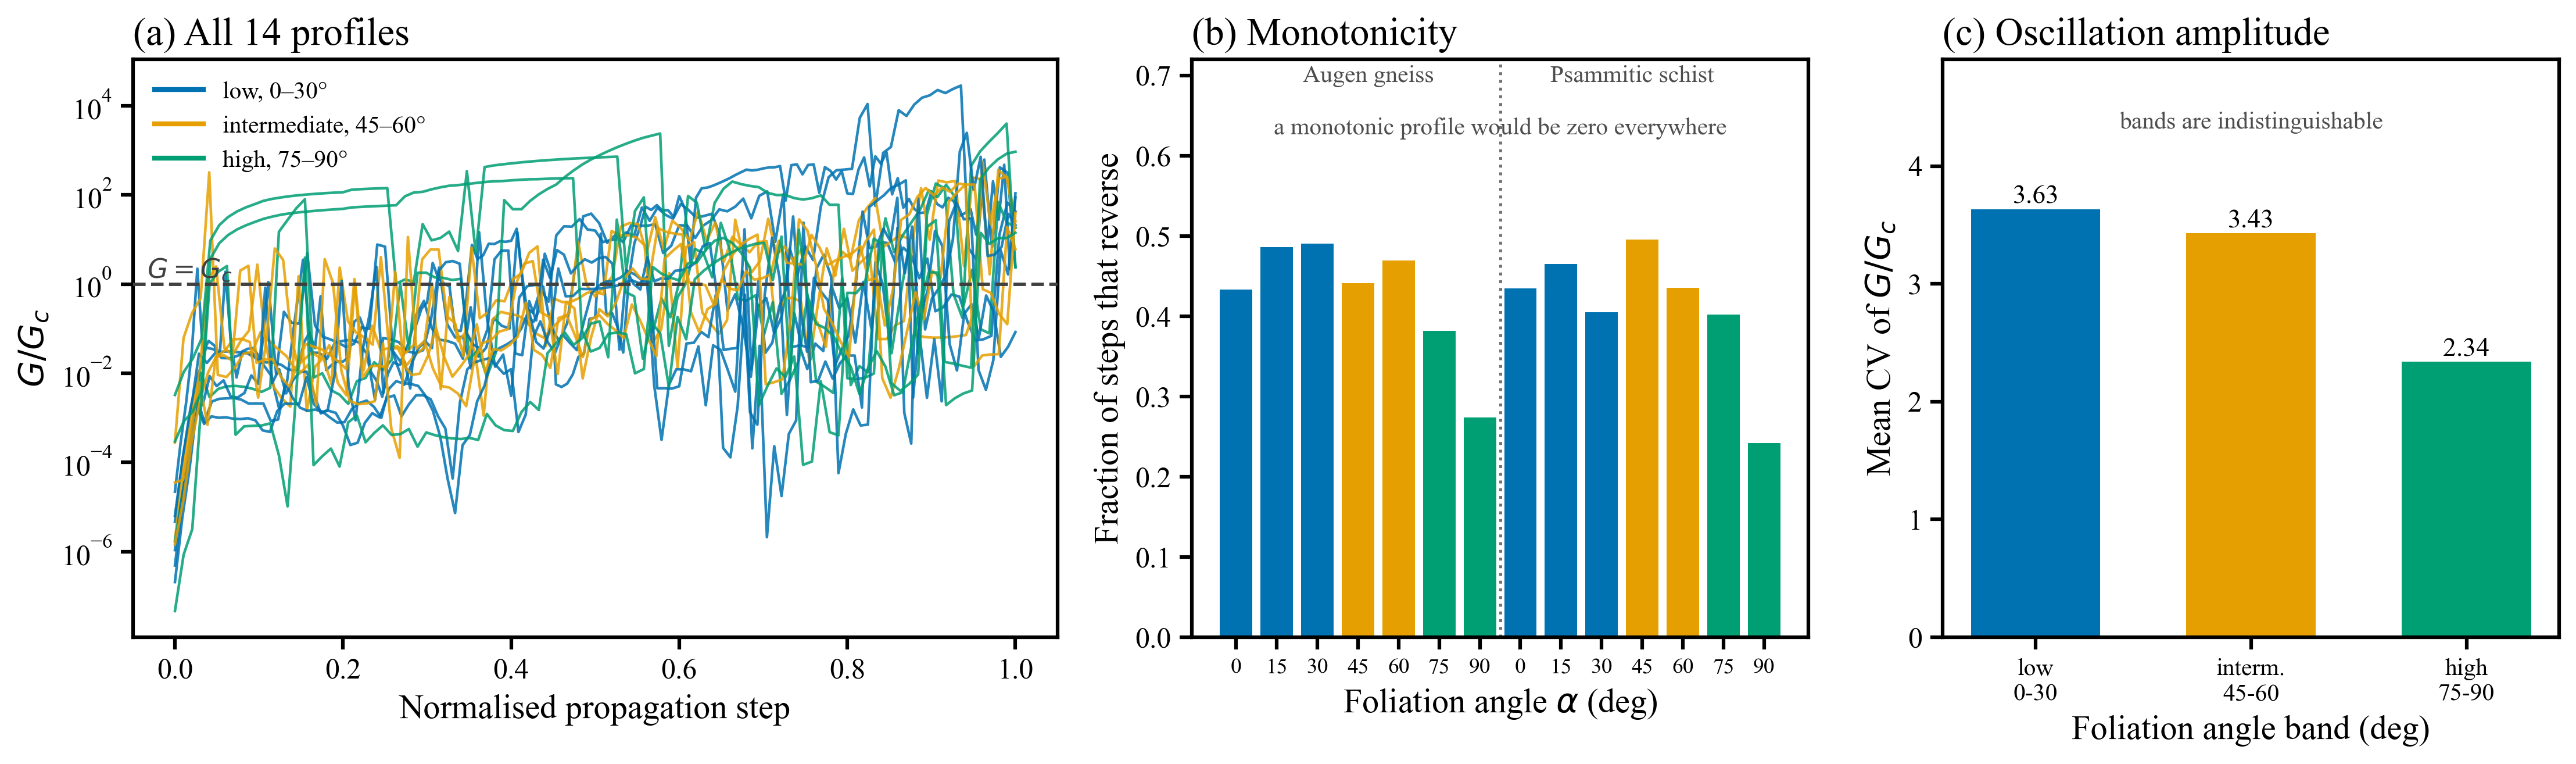

[PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/fig_S_GGc_monotonicity.pdf'),
 PosixPath('/Users/durgaacharya/Documents/Nepal_Geology/Impact_of_Rock_Structure_on_Tensile_Strength-Rupture/manuscript/fig_S_GGc_monotonicity.png')]

In [15]:
# Supplementary bounds and convergence
run("make_eshelby_supplement")
run("make_mesh_sensitivity_figure")
run("make_fig20_supplement")   # fig_S_GGc_monotonicity + its two tables

In [16]:
# The supplementary tables above are written to manuscript/tables/*.txt and
# folded into manscript_revision_001.tex between markers, so the paper stays
# one .tex file for the submission portal while the tables stay regenerable.
run("inline_tables")

# Every graphic the manuscript includes must exist
import re
tex = (REPO / "manuscript/manscript_revision_001.tex").read_text(encoding="utf-8")
graphics = sorted({m.group(1) for m in
                   re.finditer(r"includegraphics\[[^\]]*\]\{([\w./-]+)\}", tex)})
missing = [g for g in graphics
           if not (REPO / "manuscript" /
                   (g if "." in Path(g).name else g + ".pdf")).exists()]
print(f"{len(graphics)} graphics included, {len(missing)} missing")
assert not missing, missing
print("every graphic the manuscript includes is present")

all tables already current
54 graphics included, 0 missing
every graphic the manuscript includes is present
